# Double Gauss — Chief-Ray Distortion

A four-element double-Gauss photographic objective (the classic
Zeiss-Planar-derived form: two meniscus pairs symmetric about a central
aperture stop). Prescription reconstructed from the "four element double
gauss, intermediate optical design" reference lens distributed with the
open-source [rayopt-notebooks](https://github.com/quartiq/rayopt-notebooks)
project (`double_gauss.ipynb`); glass indices (SK4, F4) are d-line
(587.6 nm) values from the SCHOTT optical glass pocket catalog. It is a
textbook-scale example, not a claim of a specific commercial lens.

Unlike the [Cooke triplet](cooke_triplet.ipynb), this design's stop sits
at the geometric center of an (almost) mirror-symmetric element layout —
the classic reason double-Gauss lenses run distortion an order of
magnitude lower than an asymmetric triplet at a comparable field angle.
This notebook measures that directly, both as a dense distortion-vs-field
curve and as a warped-grid display, and the two notebooks are meant to be
read side by side.

In [1]:
from importlib import resources
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from raytracer.sequential import (
    FieldPoint, OpticalSystem, ParaxialModel, SequentialTracer,
    chief_ray_slopes, solve_object_plane, trace_from_object,
)
from raytracer.analysis import distortion_grid
from raytracer.viz import plots

CSV = resources.files("raytracer") / "data" / "double_gauss_prescription.csv"
system = OpticalSystem.from_prescription(CSV)
tracer = SequentialTracer(system)
conjugate = solve_object_plane(tracer)
efl = ParaxialModel(system).effective_focal_length()

print(f"{len(system)} surfaces, stop at index {system.stop_index}")
print(f"EFL = {efl:.3f} mm")
print(f"recovered object plane z = {conjugate.object_z:.1f} mm "
      f"(a large finite stand-in for the design's object at infinity)")
print(f"magnification = {conjugate.magnification:.6f}")

9 surfaces, stop at index 4
EFL = 98.949 mm
recovered object plane z = -10657.1 mm (a large finite stand-in for the design's object at infinity)
magnification = -0.009360


## Distortion vs. field angle

Same approach as the triplet notebook: field points are parametrized by
angle (the design's own object-angle convention, half field ~20.6°), each
angle converted to an object height at the recovered finite conjugate, and
the chief ray solved with the general 2-D solver `chief_ray_slopes` (no
manual bracket-tuning needed — unlike the coarse 1-D bracket scan used
elsewhere in this package, the general solver converges directly from a
paraxial estimate even for this huge finite-object stand-in for infinity).
Sampled densely (steps of 0.5°) out to the design's stated half field.

 field (deg) |  image y (mm) |  distortion (um) | relative (ppm)
         0.0 |        0.0000 |            0.000 |            0.0
         2.0 |       -3.4835 |           -0.032 |            9.2
         4.0 |       -6.9756 |           -0.260 |           37.3
         6.0 |      -10.4847 |           -0.898 |           85.7
         8.0 |      -14.0197 |           -2.194 |          156.5
        10.0 |      -17.5896 |           -4.454 |          253.2
        12.0 |      -21.2037 |           -8.070 |          380.6
        14.0 |      -24.8718 |          -13.550 |          544.8
        16.0 |      -28.6044 |          -21.571 |          754.1
        18.0 |      -32.4125 |          -33.039 |         1019.3
        20.0 |      -36.3080 |          -49.185 |         1354.7


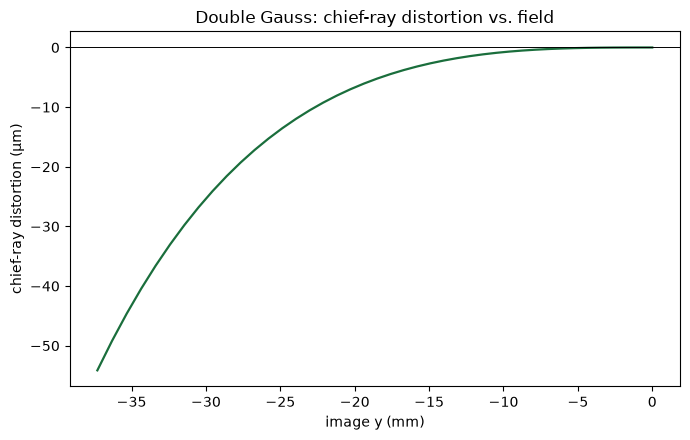

In [2]:
def chief_distortion(tracer, object_z, magnification, angle_deg, stop_index=None):
    if angle_deg == 0.0:
        return 0.0, 0.0, 0.0
    y = abs(object_z) * np.tan(np.deg2rad(angle_deg))
    sx, sy = chief_ray_slopes(tracer, FieldPoint(y=y), stop_index=stop_index)
    result = trace_from_object(tracer, (0.0, y), (sx, sy))
    ideal_y = y * magnification
    distortion_um = (result.image_point[1] - ideal_y) * 1e3
    ppm = (result.image_point[1] / ideal_y - 1) * 1e6
    return y * magnification, distortion_um, ppm


FIELDS_DEG = np.arange(0.0, 20.61, 0.5)
rows = [chief_distortion(tracer, conjugate.object_z, conjugate.magnification, deg)
        for deg in FIELDS_DEG]

image_heights = [r[0] for r in rows]
distortions_um = [r[1] for r in rows]

print(f"{'field (deg)':>12} | {'image y (mm)':>13} | {'distortion (um)':>16} | {'relative (ppm)':>14}")
for deg, (ideal_y, d_um, ppm) in list(zip(FIELDS_DEG, rows))[::4]:
    print(f"{deg:12.1f} | {ideal_y:13.4f} | {d_um:16.3f} | {ppm:14.1f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(image_heights, distortions_um, "-", color="#1a6e3c", lw=1.6)
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="image y (mm)", ylabel="chief-ray distortion (µm)",
       title="Double Gauss: chief-ray distortion vs. field")
fig.tight_layout()
plt.show()

## Distortion grid

The grid spans the design's ~20.6° half field on each axis.

grid coverage: 100.0% of 121 points traced without vignetting


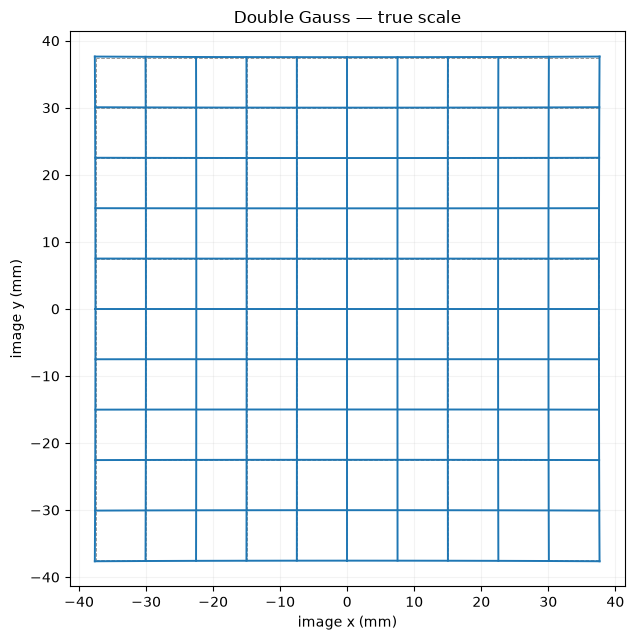

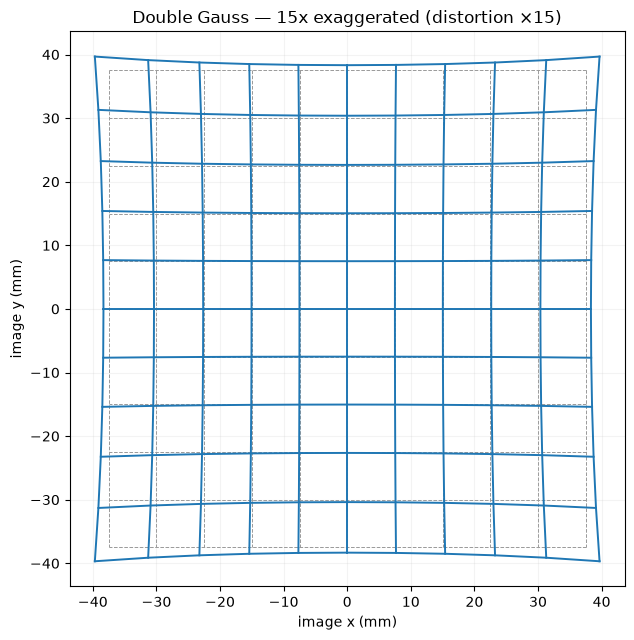

In [3]:
half = abs(conjugate.object_z) * np.tan(np.deg2rad(20.6))
grid = distortion_grid(tracer, magnification=conjugate.magnification, half_field=half, n=11)
print(f"grid coverage: {grid.valid_fraction:.1%} of {grid.valid.size} points traced without vignetting")

fig = plots.distortion_grid_figure(grid, exaggeration=1.0, title="Double Gauss — true scale")
plt.show()
fig = plots.distortion_grid_figure(grid, exaggeration=15.0, title="Double Gauss — 15x exaggerated")
plt.show()

## Triplet vs. double Gauss, at matching field angles

Comparing *relative* distortion (ppm) rather than absolute microns
controls for the two designs' different focal lengths (50 mm vs. ~99 mm)
and lets the stop-symmetry effect show through directly, over the whole
range both designs share (0 to the triplet's 12° sampling limit above).

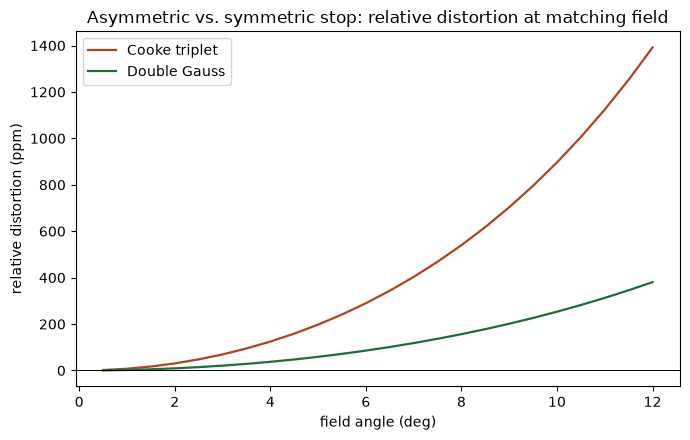

In [4]:
from raytracer.sequential import OpticalSystem as _OS, SequentialTracer as _ST, solve_object_plane as _sop

triplet_csv = resources.files("raytracer") / "data" / "cooke_triplet_prescription.csv"
triplet_system = _OS.from_prescription(triplet_csv)
triplet_tracer = _ST(triplet_system)
triplet_conjugate = _sop(triplet_tracer)

COMMON_FIELDS_DEG = np.arange(0.5, 12.01, 0.5)
triplet_ppm = [chief_distortion(triplet_tracer, triplet_conjugate.object_z,
                                 triplet_conjugate.magnification, deg)[2]
               for deg in COMMON_FIELDS_DEG]
dg_ppm = [chief_distortion(tracer, conjugate.object_z, conjugate.magnification, deg)[2]
          for deg in COMMON_FIELDS_DEG]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(COMMON_FIELDS_DEG, triplet_ppm, "-", color="#b3421b", lw=1.6, label="Cooke triplet")
ax.plot(COMMON_FIELDS_DEG, dg_ppm, "-", color="#1a6e3c", lw=1.6, label="Double Gauss")
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="field angle (deg)", ylabel="relative distortion (ppm)",
       title="Asymmetric vs. symmetric stop: relative distortion at matching field")
ax.legend()
fig.tight_layout()
plt.show()